## Classification

In [29]:
import torch 
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

%matplotlib inline

In [30]:
# change images to tensors 
transform = transforms.ToTensor()


# Load in data
train_data = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [31]:
# Setup data loader 
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

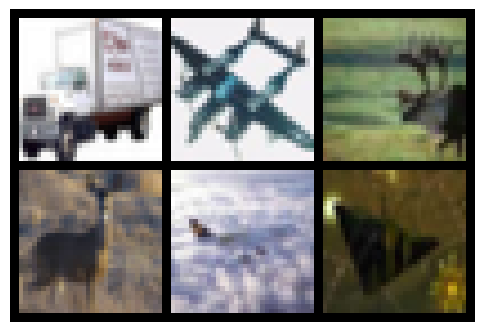

In [32]:
# Lets check some Images
from torchvision.transforms import ToPILImage
import torchvision.utils as vutils


data_iter = iter(train_loader)
images, labels = next(data_iter) 
to_pil = ToPILImage()

grid = vutils.make_grid(images[:6], nrow=3, normalize=True) #normalize=True normalizes the images
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0)) # Original channel dims is [C,H,W]. matplotlib expects [H,W,C]
plt.axis('off')
plt.show()

In [ ]:
# Lets write a model for classification


class ClassiModel(nn.Module):
    def __init__(self,in_dims,hid_dim,out_dims,n_hidden, norm):
        super().__init__()
        self.flatten = nn.Flatten()
        
        self.layers = nn.ModuleList(
            [nn.Linear(in_dims if i == 0 else hid_dim, hid_dim ) for i in range(n_hidden)]
        )
        self.output = nn.Linear(hid_dim,out_dims)
        
        if norm == "layer":
            self.norm_layers = nn.ModuleList([
                nn.LayerNorm(hid_dim)
                for _ in range(n_hidden)
            ])
        elif norm == "rms":
            self.norm_layers = nn.ModuleList([
                nn.RMSNorm(hid_dim)
                for _ in range(n_hidden)
            ])
        else:
            self.norm_layers = None

        self.norm = norm
        
        
    def forward(self,x):
        x = self.flatten(x)
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if self.norm_layers is not None:
                x = self.norm_layers[i](x)
            x = torch.relu(x)

        x = self.output(x)

        return x
        
            
        
        
        
        

In [ ]:
from torch.utils.tensorboard import SummaryWriter


def train(model, train_loader, val_loader,
          epochs, optimizer, criterion, device, norm_name):

    writer = SummaryWriter(
    log_dir=f"runs/CIFAR10/{norm_name}"
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    print(f"\nTraining: {norm_name}")

    for epoch in range(epochs):

        # -------- Training --------
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # -------- Validation --------
        model.eval()

        running_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images, labels = images.to(device), labels.to(device)

                logits = model(images)
                loss = criterion(logits, labels)

                running_loss += loss.item() * images.size(0)
                correct += (logits.argmax(1) == labels).sum().item()
                total += labels.size(0)

        val_loss = running_loss / total
        val_acc = correct / total

        # -------- TensorBoard --------
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)
        writer.add_scalar("Accuracy/train", train_acc, epoch)
        writer.add_scalar("Accuracy/val", val_acc, epoch)

        # -------- History --------
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"[{norm_name}] "
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    writer.close()

    return history

In [35]:
configs = [
    {"norm": None, "name": "NoNorm"},
    {"norm": "layer", "name": "LayerNorm"},
    {"norm": "rms", "name": "RMSNorm"},
]
device = 'cpu'
results = {}

for config in configs:

    model = ClassiModel(
        in_dims=3*32*32,
        hid_dim=128,
        out_dims=10,
        n_hidden=5,
        norm=config["norm"]
    ).to(device)

    optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

    history = train(
        model,
        train_loader,
        test_loader,
        epochs=20,
        optimizer=optimizer,
        criterion=nn.CrossEntropyLoss(),
        device=device,
        norm_name=config["name"]
    )

    results[config["name"]] = history


Training: NoNorm
[NoNorm] Epoch 01/20 | Train Loss: 2.3090 | Train Acc: 0.1000 | Val Loss: 2.3028 | Val Acc: 0.1000
[NoNorm] Epoch 02/20 | Train Loss: 2.3028 | Train Acc: 0.0980 | Val Loss: 2.3026 | Val Acc: 0.1000
[NoNorm] Epoch 03/20 | Train Loss: 2.3028 | Train Acc: 0.0972 | Val Loss: 2.3026 | Val Acc: 0.1000
[NoNorm] Epoch 04/20 | Train Loss: 2.3028 | Train Acc: 0.0988 | Val Loss: 2.3026 | Val Acc: 0.1000
[NoNorm] Epoch 05/20 | Train Loss: 2.3027 | Train Acc: 0.0994 | Val Loss: 2.3027 | Val Acc: 0.1000
[NoNorm] Epoch 06/20 | Train Loss: 2.3028 | Train Acc: 0.0984 | Val Loss: 2.3026 | Val Acc: 0.1000
[NoNorm] Epoch 07/20 | Train Loss: 2.3027 | Train Acc: 0.0983 | Val Loss: 2.3026 | Val Acc: 0.1000
[NoNorm] Epoch 08/20 | Train Loss: 2.3028 | Train Acc: 0.0982 | Val Loss: 2.3026 | Val Acc: 0.1000
[NoNorm] Epoch 09/20 | Train Loss: 2.3028 | Train Acc: 0.0980 | Val Loss: 2.3026 | Val Acc: 0.1000
[NoNorm] Epoch 10/20 | Train Loss: 2.3028 | Train Acc: 0.0969 | Val Loss: 2.3026 | Val Acc: